In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
USArrests_df = pd.read_csv('UsArrests.csv')

# Pre - processing validation
USArrests_df.info()
USArrests_df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   City      50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


City        0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

The USArrests dataset was inspected for missing values and its' structure was evaluated. No missing values were identified, and all variables are confirmed to be numeric. No additional cleaning is required to proceed with the exploratory data analysis.

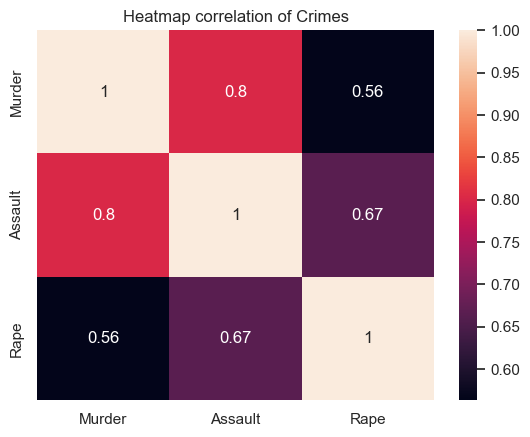

In [ ]:
#Columns of interest
assault_murder_rape = USArrests_df[['Murder','Assault','Rape']]

#Plot correlation matrix
plt.figure()
corr_coeff_mat = assault_murder_rape.corr()
sns.heatmap(corr_coeff_mat, annot=True)
plt.title("Heatmap correlation of Crimes")
plt.show()
plt.close()



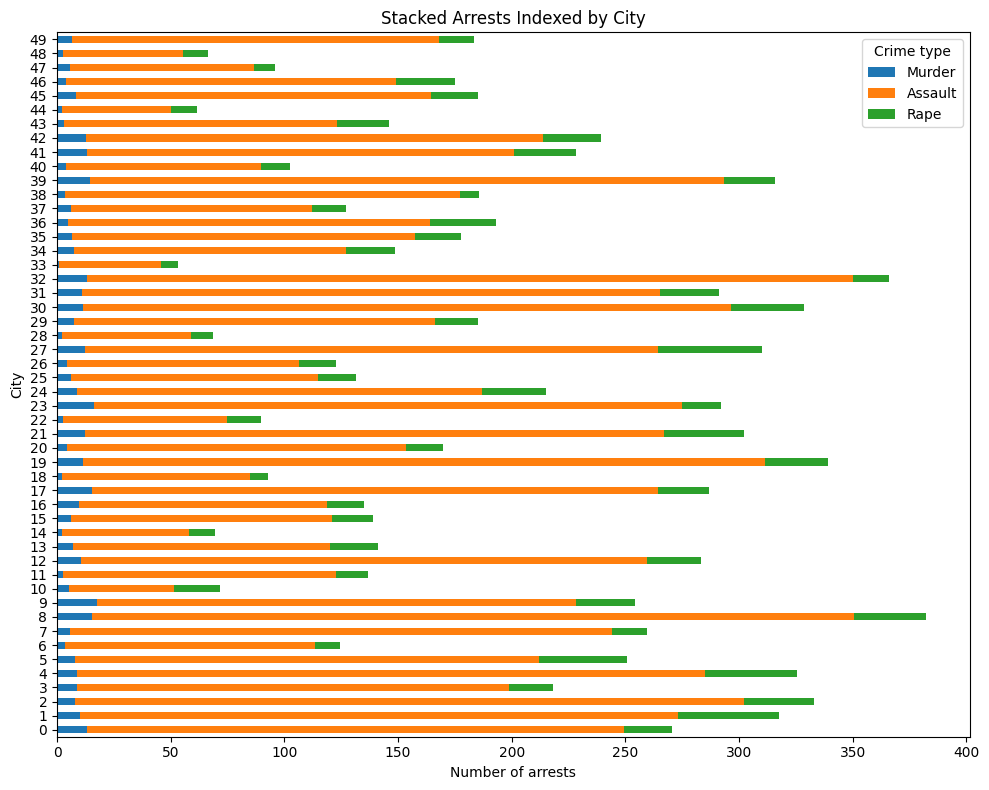

    City_Index  City
0            0     0
1            1     1
2            2     2
3            3     3
4            4     4
5            5     5
6            6     6
7            7     7
8            8     8
9            9     9
10          10    10
11          11    11
12          12    12
13          13    13
14          14    14
15          15    15
16          16    16
17          17    17
18          18    18
19          19    19
20          20    20
21          21    21
22          22    22
23          23    23
24          24    24
25          25    25
26          26    26
27          27    27
28          28    28
29          29    29
30          30    30
31          31    31
32          32    32
33          33    33
34          34    34
35          35    35
36          36    36
37          37    37
38          38    38
39          39    39
40          40    40
41          41    41
42          42    42
43          43    43
44          44    44
45          45    45
46          4

In [3]:
# X-axis
y = USArrests_df['City']

# Y values
x1 = USArrests_df['Murder']
x2 = USArrests_df['Assault']
x3 = USArrests_df['Rape']

# Create plot
USArrests_df[['Murder','Assault','Rape']].plot(kind='barh', stacked = True, figsize =(10,8))
plt.title("Stacked Arrests Indexed by City")
plt.xlabel('Number of arrests')
plt.ylabel("City")
plt.legend(title='Crime type')
plt.tight_layout()
plt.show()

# City Indexing
city_index_df = pd.DataFrame({"City_Index": range(len(USArrests_df)),"City": USArrests_df.index})
print(city_index_df)

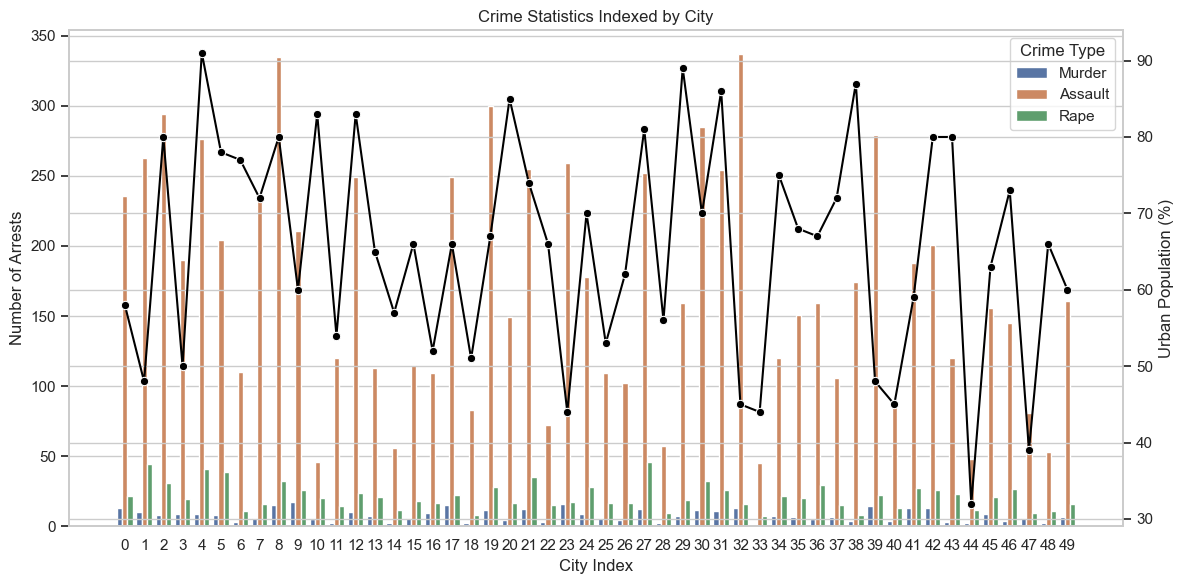

    City_Index            City
0            0         Alabama
1            1          Alaska
2            2         Arizona
3            3        Arkansas
4            4      California
5            5        Colorado
6            6     Connecticut
7            7        Delaware
8            8         Florida
9            9         Georgia
10          10          Hawaii
11          11           Idaho
12          12        Illinois
13          13         Indiana
14          14            Iowa
15          15          Kansas
16          16        Kentucky
17          17       Louisiana
18          18           Maine
19          19        Maryland
20          20   Massachusetts
21          21        Michigan
22          22       Minnesota
23          23     Mississippi
24          24        Missouri
25          25         Montana
26          26        Nebraska
27          27          Nevada
28          28   New Hampshire
29          29      New Jersey
30          30      New Mexico
31      

In [4]:
# Set City as the index
USArrests_df.set_index("City", inplace=True)

# Prepare data for seaborn
crime_data = USArrests_df.reset_index().melt(id_vars=["City", "UrbanPop"],value_vars=["Murder", "Assault", "Rape"],var_name="Crime Type",value_name="Number of Arrests")

# Create a numeric index for plotting
crime_data["City_Index"] = crime_data.groupby("City").ngroup()

urbanpop_data = USArrests_df.reset_index()
urbanpop_data["City_Index"] = range(len(urbanpop_data))

# Create the plot
sns.set_theme(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for crime statistics
sns.barplot(data=crime_data,x="City_Index",y="Number of Arrests",hue="Crime Type",ax=ax1)

ax1.set_title("Crime Statistics Indexed by City")
ax1.set_xlabel("City Index")
ax1.set_ylabel("Number of Arrests")

# Secondary axis for UrbanPop
ax2 = ax1.twinx()
sns.lineplot(data=urbanpop_data,x="City_Index",y="UrbanPop",marker="o",color="black",ax=ax2)
ax2.set_ylabel("Urban Population (%)")
plt.tight_layout()
plt.show()

# City indexing
city_index_df = pd.DataFrame({"City_Index": range(len(USArrests_df)),"City": USArrests_df.index})
print(city_index_df)

